In [ ]:
import setup
import excel_sheet_functions as ex
from rocketpy import Rocket

In [89]:
env = setup.get_env_reanalysis(date=(2025,5,30, 12))
ox_tank, fuel_tank = setup.create_tanks()
motor = setup.create_motor((ox_tank, fuel_tank))
rocket = setup.create_rocket(motor)
flight = setup.create_flight(rocket, env, inclination=87, heading=270)

In [ ]:
flight.all_info()

In [ ]:
ex.average_thrust_during_rail_phase(flight, motor, rocket)
print(ex.max_pitch_moment(flight))
ex.max_yaw_moment(flight)

In [ ]:
ex.calculate_aero_centers(rocket, flight)
ex.plot_aerodynamic_stability(rocket, flight)
ex.plot_cp_vs_mach_number(rocket, flight)

In [ ]:
ex.analyze_advanced_damping(flight, signal_name="partial_angle_of_attack")

In [ ]:
ex.analyze_and_plot_damping(flight)

In [90]:
ex.distance_from_pad(flight)

np.float64(2467.4012974021757)

In [91]:
trb = Rocket(
    radius=0.1,
    mass=58.367, 
    inertia=(75.502, 75.502, 0.43), 
    power_off_drag=".\\data\\powerondrag.csv",  
    power_on_drag='.\\data\\powerondrag.csv',
    center_of_mass_without_motor=2.75, 
    coordinate_system_orientation="nose_to_tail", 
)
trb.add_motor(motor, position=4.49)
#Aerodynamic surfaces taken from openrocket
nose_cone = trb.add_nose(
    length=0.7, kind="lvhaack", position=0
)

fin_set = trb.add_trapezoidal_fins(
    n=4,
    root_chord=0.287,
    tip_chord=0.059,
    span=0.202,
    sweep_length=0.228,
    position=4.21,
    cant_angle=0,
)

tail = trb.add_tail(
    top_radius=0.1, bottom_radius=0.065, length=0.287, position=4.21
)

rail_buttons = trb.set_rail_buttons(
    upper_button_position=2.17, #Just some value, not accurate
    lower_button_position=3.5, #Just some value, not accurate
    angular_position=0, #Just some value, not accurate #0 stopni
)

# main = trb.add_parachute(
#     name="main",
#     cd_s=12.72, # cd * parachute area
#     trigger=1000,      
#     sampling_rate=105,
#     lag=6,
#     noise=(0, 8.3, 0.5),
#     radius=2.25, 
#     height=2.25,
#     porosity=0.0432,
# )

drogue = trb.add_parachute(
    name="drogue",
    cd_s=1.218,
    trigger="apogee", 
    sampling_rate=105,
    lag=1,
    noise=(0, 8.3, 0.5),
    radius=0.76,
    height=0.76,
    porosity=0.0432,
)

In [92]:
flight_no_main = setup.create_flight(trb, env, inclination=87, heading=270)

In [93]:
flight_no_main.parachute_events
ex.distance_from_pad(flight_no_main)

np.float64(2470.28034073606)

In [94]:
trb_no_parachutes = Rocket(
    radius=0.1,
    mass=58.367, 
    inertia=(75.502, 75.502, 0.43), 
    power_off_drag=".\\data\\powerondrag.csv",  
    power_on_drag='.\\data\\powerondrag.csv',
    center_of_mass_without_motor=2.75, 
    coordinate_system_orientation="nose_to_tail", 
)
trb_no_parachutes.add_motor(motor, position=4.49)
#Aerodynamic surfaces taken from openrocket
nose_cone = trb_no_parachutes.add_nose(
    length=0.7, kind="lvhaack", position=0
)

fin_set = trb_no_parachutes.add_trapezoidal_fins(
    n=4,
    root_chord=0.287,
    tip_chord=0.059,
    span=0.202,
    sweep_length=0.228,
    position=4.21,
    cant_angle=0,
)

tail = trb_no_parachutes.add_tail(
    top_radius=0.1, bottom_radius=0.065, length=0.287, position=4.21
)

rail_buttons = trb_no_parachutes.set_rail_buttons(
    upper_button_position=2.17, #Just some value, not accurate
    lower_button_position=3.5, #Just some value, not accurate
    angular_position=0, #Just some value, not accurate #0 stopni
)

# main = trb.add_parachute(
#     name="main",
#     cd_s=12.72, # cd * parachute area
#     trigger=1000,      
#     sampling_rate=105,
#     lag=6,
#     noise=(0, 8.3, 0.5),
#     radius=2.25, 
#     height=2.25,
#     porosity=0.0432,
# )

# drogue = trb.add_parachute(
#     name="drogue",
#     cd_s=1.218,
#     trigger="apogee", 
#     sampling_rate=105,
#     lag=1,
#     noise=(0, 8.3, 0.5),
#     radius=0.76,
#     height=0.76,
#     porosity=0.0432,
# )

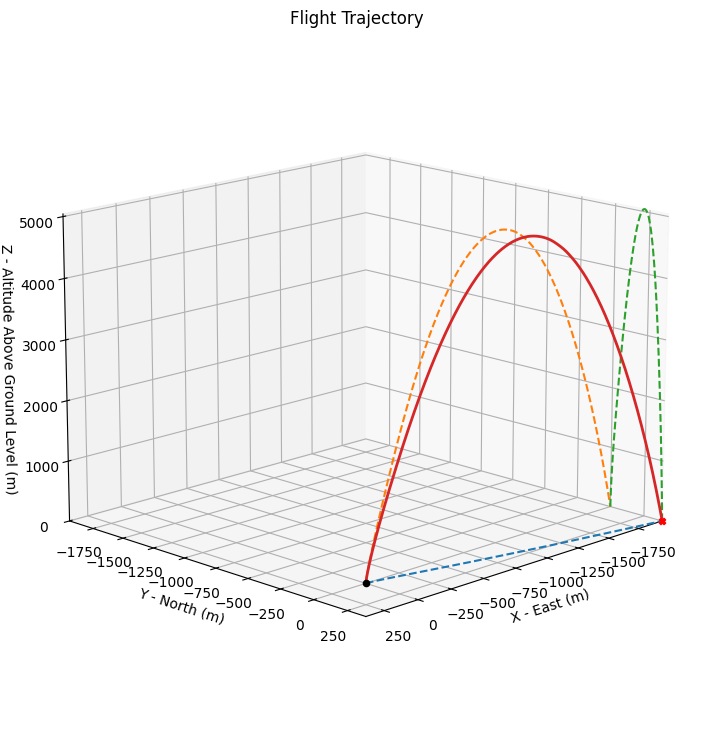

In [95]:
flight_no_parachutes = setup.create_flight(trb_no_parachutes, env, inclination=87, heading=270)
flight_no_parachutes.plots.trajectory_3d()

In [96]:
ex.distance_from_pad(flight_no_parachutes)

np.float64(1987.0404831265525)